<a href="https://colab.research.google.com/github/iniguezd/cartagenaD0aChatGPT/blob/main/dia1/3_regularizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerías

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_iris
import copy

# Definición de la red

In [2]:
# Vamos a añadir una capa lineal oculta con función de activación ReLU
class IrisMLP(nn.Module):
    def __init__(self, hidden_dim: int = 16):
        super().__init__()
        self.fc1 = nn.Linear(4, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.relu(self.fc1(x))   # (B, 16)
        logits = self.fc2(h)         # (B, 3)
        return logits

# Dataset y Dataloader

In [3]:
class IrisDataset(Dataset):
    def __init__(self):
        data = load_iris()
        self.X = torch.tensor(
            data.data, dtype=torch.float32
        )  # (150, 4)
        self.y = torch.tensor(
            data.target, dtype=torch.long
        )  # (150,)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [4]:
full_iris_dataset = IrisDataset()
train_dataset, test_dataset, val_dataset = torch.utils.data.random_split(full_iris_dataset, [0.7, 0.2, 0.1], generator=torch.Generator().manual_seed(42))

In [5]:
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Ejercicio 1

Haz el entrenamiento de la red durante 100 epochs, reportando el loss de entrenamiento en cada epoch. Finalmente dibuja la gráfica del loss de entrenamiento a lo largo de las epochs.

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_iris

In [11]:
!pip install torchviz

In [12]:
from torchviz import make_dot

In [42]:
# En PyTorch, los datasets deben heredar de torch.utils.data.Dataset
class IrisDataset(Dataset):
    # Inicializamos el dataset cargando los datos
    def __init__(self):
        data = load_iris()
        self.X = torch.tensor(
            data.data, dtype=torch.float32
        )  # (150, 4)
        self.y = torch.tensor(
            data.target, dtype=torch.long
        )  # (150,)

    # PyTorch necesita saber el tamaño del dataset
    def __len__(self):
        return self.X.shape[0]

    # PyTorch necesita poder indexar el dataset
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [43]:
full_iris_dataset = IrisDataset()

class IrisRed(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.fc1(x)   # (B, 3)
        return h

# el softmax no se suele incluir en el modelo porque
# 1) la función de pérdida CrossEntropyLoss ya lo incluye
# 2) y porque en inferencia se suele usar argmax (selección de la clase con mayor puntuación)

In [44]:
# instanciar modelo, loss y optimizador
# si se dispone de GPU, mover el modelo a GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# la red se inicializa a pesos aleatorios cada vez que se instancia
model = IrisRed().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

In [45]:
# esta función devuelve un iterador sobre batches
dataloader = DataLoader(full_iris_dataset, batch_size=16, shuffle=True)
# por otro lado, la red se ha definido para procesar batches de datos

In [46]:
num_epochs = 100

train_losses = []
# durante un número de epochs
for epoch in range(1, num_epochs + 1):
    # poner el modelo en modo entrenamiento
    model.train()
    # para llevar la cuenta del loss
    running_loss = 0.0
    n_seen = 0
    for xB, yB in dataloader:
        xB, yB = xB.to(device), yB.to(device)
        optimizer.zero_grad()      # reset gradientes
        logits = model(xB)         # forward
        loss = criterion(logits, yB)
        loss.backward()            # backward
        optimizer.step()           # update
        running_loss += loss.item() * xB.size(0) # para llevar la cuenta del loss
        n_seen += xB.size(0)           # para llevar la cuenta del loss
    epoch_loss = running_loss / n_seen # loss medio en la epoch
    print(f"Epoch {epoch:03d} | train_loss = {epoch_loss:.4f}") # reportamos el loss

    train_losses.append(epoch_loss);

Epoch 001 | train_loss = 1.5691
Epoch 002 | train_loss = 1.0662
Epoch 003 | train_loss = 0.9088
Epoch 004 | train_loss = 0.8611
Epoch 005 | train_loss = 0.8228
Epoch 006 | train_loss = 0.7981
Epoch 007 | train_loss = 0.7651
Epoch 008 | train_loss = 0.7473
Epoch 009 | train_loss = 0.7276
Epoch 010 | train_loss = 0.7027
Epoch 011 | train_loss = 0.6907
Epoch 012 | train_loss = 0.6829
Epoch 013 | train_loss = 0.6601
Epoch 014 | train_loss = 0.6466
Epoch 015 | train_loss = 0.6372
Epoch 016 | train_loss = 0.6241
Epoch 017 | train_loss = 0.6140
Epoch 018 | train_loss = 0.6075
Epoch 019 | train_loss = 0.5990
Epoch 020 | train_loss = 0.5877
Epoch 021 | train_loss = 0.5809
Epoch 022 | train_loss = 0.5734
Epoch 023 | train_loss = 0.5640
Epoch 024 | train_loss = 0.5597
Epoch 025 | train_loss = 0.5507
Epoch 026 | train_loss = 0.5466
Epoch 027 | train_loss = 0.5431
Epoch 028 | train_loss = 0.5419
Epoch 029 | train_loss = 0.5309
Epoch 030 | train_loss = 0.5304
Epoch 031 | train_loss = 0.5204
Epoch 03

In [32]:
epoch_loss = running_loss / len(train_dataloader)

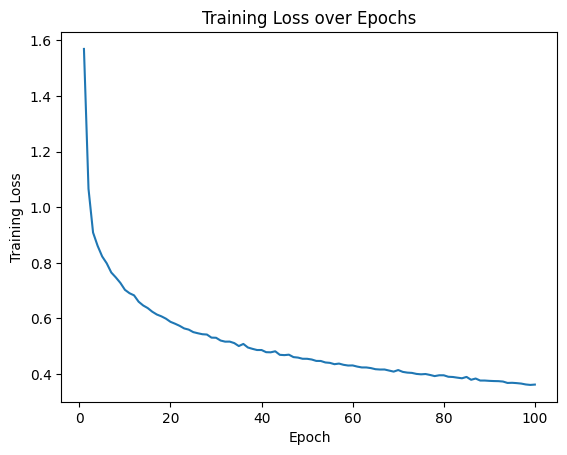

In [47]:
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss over Epochs")
plt.show()

# Ejercicio 2

Antes de finalizar cada epoch, obtén el loss de validación. Haz otra gráfica que muestre ambos losses. Interpreta la gráfica.

# Ejercicio 3

Escoge una de estas dos opciones:
- Implementa early stopping con X epochs de paciencia.
- Implementa un mecanismo de guardar el mejor modelo y monitorización del loss de validación durante el entrenamiento.

**Nota.** Para guardar y restaurar el estado de la red:
```python
best_state = copy.deepcopy(model.state_dict())
model.load_state_dict(best_state)
```

# Ejercicio 4

Evalúa la mejor red obtenida en el apartado anterior. Usa `accuracy` como métrica.

In [ ]:
def evaluate_accuracy(loader, model, device):
    # TODO
    pass

accuracy = evaluate_accuracy(test_dataloader, model, device)
print(f"Accuracy en el conjunto de test: {accuracy:.2f}%")

# Ejercicio 5

Aumenta la hidden dimension a 1024 e implementa algún método de regularización visto en clase ($L_1,L_2$ o dropout).
- [`nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html)
- [`weight_decay`](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html)
- Para $L_1$ hay que hacerla a mano, añadiendo la norma $L_1$ de los parámetros al loss.
